# Phase 4 — Risk Model
## Task 4.1 — Volatiolity Targeting
### Step 1 — Build Trend Strategy v2 on Train


带vol targeting 的完整回测函数

杠杆率控制在3倍

In [2]:
#这两行代码是告诉ipynb，只要我运行cell，就去检查旁边.py文件看有没有被修改，如果修改了就重新读入

#读取之前用的函数
from functions import metrics_from_bt
#读取本地数据的代码
import pandas as pd
import numpy as np

# 1. 一步到位：读取 CSV，同时告诉 Pandas 把第 0 列当成索引，并尝试解析为时间格式
clean_data_path = "data/BTCUSDT_1h_6y_cleaned.csv"
df = pd.read_csv(clean_data_path, index_col=0, parse_dates=True)

# 2. (可选) 终极保险：强制确认一下索引是 UTC 时区格式
# 有时候 CSV 存取会丢失时区信息，加上这句可以保证万无一失
df.index = pd.to_datetime(df.index, utc=True)

# 检查结果
print("数据前 3 行：\n", df.head(3))
print("\n当前的索引类型：\n", type(df.index))

df6y=df

# 1) 全数据
df_full = df6y.copy()
df_full = df_full.sort_index()

# 2) 数据长度
n = len(df_full)

# 3) 切分位置
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# 4) 三段数据
train_df = df_full.iloc[:train_end].copy()
val_df   = df_full.iloc[train_end:val_end].copy()
test_df  = df_full.iloc[val_end:].copy()
print("Total rows :", len(df_full))
print("Train rows :", len(train_df))
print("Val rows   :", len(val_df))
print("Test rows  :", len(test_df))

数据前 3 行：
                               open     high      low    close       volume  \
2020-03-01 00:00:00+00:00  8523.61  8613.57  8511.11  8547.25  1952.740520   
2020-03-01 01:00:00+00:00  8546.65  8649.00  8514.06  8639.28  1901.273287   
2020-03-01 02:00:00+00:00  8640.23  8675.00  8617.73  8630.86  1271.182357   

                                                 close_time  \
2020-03-01 00:00:00+00:00  2020-03-01 00:59:59.999000+00:00   
2020-03-01 01:00:00+00:00  2020-03-01 01:59:59.999000+00:00   
2020-03-01 02:00:00+00:00  2020-03-01 02:59:59.999000+00:00   

                           quote_asset_volume  number_of_trades  \
2020-03-01 00:00:00+00:00        1.673789e+07           22876.0   
2020-03-01 01:00:00+00:00        1.630347e+07           24731.0   
2020-03-01 02:00:00+00:00        1.098729e+07           16257.0   

                           taker_buy_base_asset_volume  \
2020-03-01 00:00:00+00:00                   899.851144   
2020-03-01 01:00:00+00:00              

### 首先是单期48/336带波的控制回测 V2

In [3]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 1 — Single-horizon trend strategy v2
# ============================================

import numpy as np
import pandas as pd

ANNUAL_HOURS = 24 * 365

def backtest_single_horizon_vol_target(
    df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
):
    data = df.copy().sort_index()

    # 1) 市场收益率
    ret = data["close"].pct_change()

    # 2) EMA 趋势信号
    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0

    # 3) 市场波动率（用于 signal 标准化 + 仓位控制）
    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)

    # 4) 风险调整信号
    signal = trend / realized_vol

    # 5) 方向仓位：只决定多空方向和强弱，不决定最终杠杆 direction>0偏多，小于零偏空
    direction = np.tanh(signal).fillna(0)

    # 6) 把年化目标波动率转成小时目标波动率
    target_vol_hourly = target_vol_annual / np.sqrt(ANNUAL_HOURS)

    # 7) vol targeting 仓位大小
    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0)
            #防止目标波动率/当前波动率过大，加一个上线，为三倍仓位
    # 8) 最终目标仓位 = 方向 × 仓位大小
    target_pos = direction * size

    # 9) 避免未来函数：下一根K线才真正持仓
    pos = target_pos.shift(1).fillna(0)

    # 10) 换手与手续费
    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    # 11) 策略收益
    strategy_ret = pos * ret - cost

    # 12) 资金曲线
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    # 13) 回撤
    peak = equity.cummax()
    drawdown = equity / peak - 1

    # 14) 打包结果
    bt = pd.DataFrame({
        "close": data["close"],
        "ret": ret,
        "trend": trend,
        "realized_vol": realized_vol,
        "signal": signal,
        "direction": direction,
        "size": size,
        "target_pos": target_pos,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

bt_train_v2 = backtest_single_horizon_vol_target(
    train_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_train_v2 = metrics_from_bt(bt_train_v2)

print("=== Trend Strategy v2 (Vol Targeting) on TRAIN ===")
print("Sharpe, MaxDD, TotalRet =", metrics_train_v2)

bt_train_v2[["direction", "size", "pos", "equity", "drawdown"]].tail()

=== Trend Strategy v2 (Vol Targeting) on TRAIN ===
Sharpe, MaxDD, TotalRet = (0.49169118073525825, -0.23235705863932254, 0.3536197702912536)


,direction,size,pos,equity,drawdown
2023-10-06 10:00:00+00:00,0.999956,0.695141,0.691693,1.356355,-0.097406
2023-10-06 11:00:00+00:00,0.999958,0.693035,0.695110,1.359403,-0.095378
2023-10-06 12:00:00+00:00,0.999623,0.569799,0.693006,1.342196,-0.106829
2023-10-06 13:00:00+00:00,0.999406,0.544885,0.569584,1.349791,-0.101775
2023-10-06 14:00:00+00:00,0.999472,0.551705,0.544561,1.353620,-0.099227


#### 和不加波动率控制比一下

In [4]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 3 — Compare old vs new on TRAIN
# ============================================
#和不加波动率控制的比较
def backtest_single_horizon_basic(df, ema_fast=48, ema_slow=336, fee_rate=0.0004):
    data = df.copy().sort_index()

    ret = data["close"].pct_change()
    vol = ret.ewm(span=24 * 7, adjust=False).std()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0
    signal = trend / vol

    pos = np.tanh(signal).shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    strategy_ret = pos * ret - cost
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

bt_train_v1 = backtest_single_horizon_basic(train_df, ema_fast=48, ema_slow=336)
metrics_train_v1 = metrics_from_bt(bt_train_v1)

print("=== TRAIN COMPARISON ===")
print("v1 | Single Horizon Basic       :", metrics_train_v1)
print("v2 | Single Horizon Vol Target  :", metrics_train_v2)

=== TRAIN COMPARISON ===
v1 | Single Horizon Basic       : (0.3884326023845295, -0.6113506289830805, 0.12398222187638641)
v2 | Single Horizon Vol Target  : (0.49169118073525825, -0.23235705863932254, 0.3536197702912536)


这一结果显示vol targeting部分非常有效果，在CTA策略中，主要是小时间的大趋势赚钱，其他大部分时间都是在市场的震荡中，加入这一部分可以让回撤被压制，风险可控

下一步去验证风险模型在validation集是否稳健

In [6]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 4 — Run on VALIDATION
# ============================================
#v2在validation 运行

bt_val_v2 = backtest_single_horizon_vol_target(
    val_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_val_v2 = metrics_from_bt(bt_val_v2)

print("=== Trend Strategy v2 (Vol Targeting) on VALIDATION ===")
print("Sharpe, MaxDD, TotalRet =", metrics_val_v2)

bt_val_v1 = backtest_single_horizon_basic(val_df, ema_fast=48, ema_slow=336)

metrics_val_v1 = metrics_from_bt(bt_val_v1)

print("=== VALIDATION COMPARISON ===")
print("v1 | Basic       :", metrics_val_v1)
print("v2 | Vol Target  :", metrics_val_v2)

=== Trend Strategy v2 (Vol Targeting) on VALIDATION ===
Sharpe, MaxDD, TotalRet = (1.540549589245343, -0.17667301139414526, 0.4440289491193421)
=== VALIDATION COMPARISON ===
v1 | Basic       : (1.5534435936588291, -0.3819392869747842, 1.1400380947050541)
v2 | Vol Target  : (1.540549589245343, -0.17667301139414526, 0.4440289491193421)


sharpe没变，但是风险减半，这是vol的典型效果，风险稳定化。

为什么return下降?

因为basic的模型，其实没控制杠杆，v2模型leverage变低，原始策略有时候仓位会很大，这当然也会导致drawdown也很大

接下里，让模型在test上运行。

In [7]:
# ============================================
# Phase 4 — Risk Model
# Task 4.1 — Volatility Targeting
# Step 5 — Run on TEST
# ============================================

bt_test_v2 = backtest_single_horizon_vol_target(
    test_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_test_v2 = metrics_from_bt(bt_test_v2)

print("=== Trend Strategy v2 (Vol Targeting) on TEST ===")
print("Sharpe, MaxDD, TotalRet =", metrics_test_v2)

bt_test_v1 = backtest_single_horizon_basic(test_df, ema_fast=48, ema_slow=336)

metrics_test_v1 = metrics_from_bt(bt_test_v1)

print("=== TEST COMPARISON ===")
print("v1 | Basic       :", metrics_test_v1)
print("v2 | Vol Target  :", metrics_test_v2)

=== Trend Strategy v2 (Vol Targeting) on TEST ===
Sharpe, MaxDD, TotalRet = (0.5931311592657338, -0.14342195638680566, 0.12978893473956998)
=== TEST COMPARISON ===
v1 | Basic       : (0.49782740805767106, -0.30426978619031253, 0.15793000930344525)
v2 | Vol Target  : (0.5931311592657338, -0.14342195638680566, 0.12978893473956998)


这一结果不错，在使用vol组件之后明显发现最大回撤显著降低。

但是我们还缺一个关键组件，我们之前观察到，trend strategy大部分时间是在震荡的，所以问题是 Whipsaw，信号的反复会导致**反复交易**升高成本

解决这个问题的经典方法是**signal threshold** 信号阈值

在信号很小的时候|signal|很小，这时候去交易，其实信号是个噪声，

所以在CTA系统加入，|signal|> threshold  可以控制弱信号不交易，减少振荡周期交易

大部分ema_fast/eam_slow-1是负数，正负决定方向，大小决定强度。所以绝对值更重要。

通常signal threshold一般在0.2-1之间，所以我们一般不会固定选一个值，而是做\
threshold scan

## Task4.2 Signal Threshold
### Step2 Threshold Scan on Train

搜索threshold值的单期回测函数，ema trend+threshold+vol

In [8]:
# ============================================
# Phase 4 — Risk Model
# Task 4.2 — Signal Threshold
# Step 2 — Threshold scan on TRAIN
# ============================================

def backtest_single_horizon_threshold(
    df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold=0.0,
    fee_rate=0.0004,
    max_leverage=3.0
):

    data = df.copy().sort_index()

    ret = data["close"].pct_change()

    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1

    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)

    signal = trend / realized_vol

    # -------- threshold filter --------
    filtered_signal = signal.copy()
    filtered_signal[abs(filtered_signal) < threshold] = 0

    direction = np.tanh(filtered_signal).fillna(0)

    target_vol_hourly = target_vol_annual / np.sqrt(24 * 365)

    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0)

    target_pos = direction * size

    pos = target_pos.shift(1).fillna(0)

    turnover = pos.diff().abs().fillna(0)

    cost = fee_rate * turnover

    strat_ret = pos * ret - cost

    equity = (1 + strat_ret).cumprod()

    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "pos": pos,
        "turnover": turnover,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown
    })

    return bt


threshold_list = [0, 0.2, 0.3, 0.5, 1]

results = []

for th in threshold_list:

    bt = backtest_single_horizon_threshold(
        train_df,
        threshold=th
    )

    sharpe, maxdd, ret = metrics_from_bt(bt)

    turnover = bt["turnover"].sum()

    results.append({
        "threshold": th,
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret,
        "turnover": turnover
    })

scan_df = pd.DataFrame(results)

scan_df


,threshold,sharpe,maxdd,ret,turnover
0,0.0,0.491691,-0.232357,0.353620,293.905318
1,0.2,0.497516,-0.230280,0.359864,292.572185
2,0.3,0.501319,-0.231028,0.363920,293.010587
3,0.5,0.534431,-0.235166,0.399828,291.912008
4,1.0,0.543752,-0.211515,0.406902,283.927285


turnover是交易强度，turnover是绝对值变化 比如0.2变为-0.3，turnover就是0.5

### Step3 Threshold Scan on Validation
看threshold这个参数有没有鲁棒性

In [9]:
# ============================================
# Phase 4 — Risk Model
# Task 4.2 — Signal Threshold
# Step 3 — Threshold scan on VALIDATION
# ============================================

threshold_list = [0, 0.2, 0.3, 0.5, 1]

results_val = []

for th in threshold_list:

    bt_val_th = backtest_single_horizon_threshold(
        val_df,
        ema_fast=48,
        ema_slow=336,
        vol_lookback=72,
        target_vol_annual=0.20,
        threshold=th,
        fee_rate=0.0004,
        max_leverage=3.0
    )

    sharpe, maxdd, ret = metrics_from_bt(bt_val_th)
    turnover = bt_val_th["turnover"].sum()

    results_val.append({
        "threshold": th,
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret,
        "turnover": turnover
    })

scan_val_threshold_df = pd.DataFrame(results_val)

print("=== VALIDATION THRESHOLD SCAN ===")
print(scan_val_threshold_df)

=== VALIDATION THRESHOLD SCAN ===
   threshold    sharpe     maxdd       ret   turnover
0        0.0  1.540550 -0.176673  0.444029  93.617743
1        0.2  1.566342 -0.176400  0.453550  93.456741
2        0.3  1.569033 -0.177425  0.454428  93.783227
3        0.5  1.461162 -0.182237  0.414167  95.157496
4        1.0  1.446829 -0.183639  0.405866  93.756643


画validation集的threshold曲线

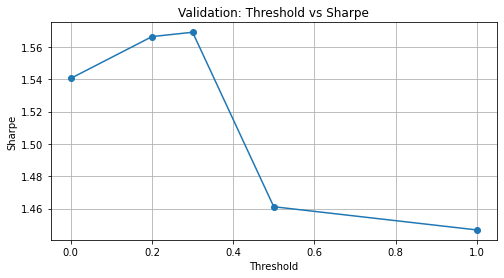

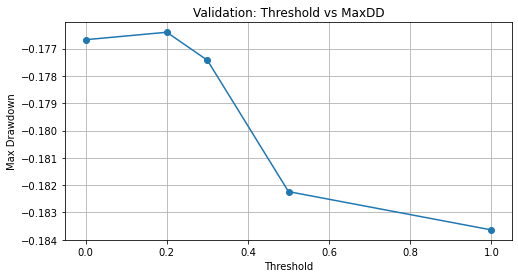

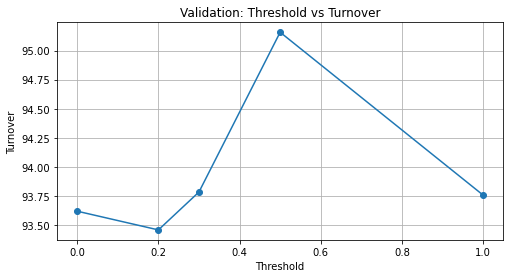

In [10]:
# ============================================
# Phase 4 — Risk Model
# Task 4.2 — Signal Threshold
# Step 4 — Plot validation threshold curves
# ============================================

import matplotlib.pyplot as plt

# 1) Sharpe
plt.figure(figsize=(8, 4))
plt.plot(scan_val_threshold_df["threshold"], scan_val_threshold_df["sharpe"], marker="o")
plt.title("Validation: Threshold vs Sharpe")
plt.xlabel("Threshold")
plt.ylabel("Sharpe")
plt.grid(True)
plt.show()

# 2) Max Drawdown
plt.figure(figsize=(8, 4))
plt.plot(scan_val_threshold_df["threshold"], scan_val_threshold_df["maxdd"], marker="o")
plt.title("Validation: Threshold vs MaxDD")
plt.xlabel("Threshold")
plt.ylabel("Max Drawdown")
plt.grid(True)
plt.show()

# 3) Turnover
plt.figure(figsize=(8, 4))
plt.plot(scan_val_threshold_df["threshold"], scan_val_threshold_df["turnover"], marker="o")
plt.title("Validation: Threshold vs Turnover")
plt.xlabel("Threshold")
plt.ylabel("Turnover")
plt.grid(True)
plt.show()

TRAIN
| threshold | Sharpe |
| --------- | ------ |
| 0         | 0.50   |
| 0.3       | 0.51   |
| 0.5       | 0.54   |
| 1         | 0.55   |


VALIDATION
| threshold | Sharpe |
| --------- | ------ |
| 0         | 1.56   |
| 0.2       | 1.59   |
| 0.3       | 1.59   |
| 0.5       | 1.48   |
| 1         | 1.47   |

threshold 在0.2-0.3区域内是比较稳定的

下一步我们把threshold=0.3放在test集去看

In [11]:
bt_test_v3 = backtest_single_horizon_threshold(
    test_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold=0.3,
    fee_rate=0.0004,
    max_leverage=3.0
)

metrics_test_v3 = metrics_from_bt(bt_test_v3)


print("===  COMPARISON on Test ===")
print("v1 | Basic       :", metrics_test_v1)
print("v2 | Vol Target  :", metrics_test_v2)
print("v3 | vol Target+Threshold(0.3)  :", metrics_test_v3)

===  COMPARISON on Test ===
v1 | Basic       : (0.49782740805767106, -0.30426978619031253, 0.15793000930344525)
v2 | Vol Target  : (0.5931311592657338, -0.14342195638680566, 0.12978893473956998)
v3 | vol Target+Threshold(0.3)  : (0.6185999680770276, -0.14389053021431109, 0.13694056130638743)


对于threshold，因为signal的分布会随着市场的regime改变，所以很多CTA都会用：\
Dynamic threshold 也就是动态阈值

动态阈值怎么选，一般用 signal percentile 信号百分位数比较合理：

abs(signal) > rolling_percentile(abs(signal), q)

这个rolling_percentil的窗口，本质上实在控制threshold学习市场状态的速度。对于1小时数据，窗口太短threshold容易变化太快，容易被短期噪音带着跑，过滤器本身不稳定，太长太迟钝。中等窗口比较合适。


## Task4.3 Dynamic Threshold
### Step1 Rolling percentil threshold

1）threshold类型 我们就用abs（signal）

2）percentile值，我们先扫q_list=[0.6,0.7,0.8]\
    即交易最近窗口里强度排名前40%，30%，20%

3）rolling window  window_list = [七天, 14天, 24天]

这里这个dynamic threshold逻辑：

首先，先取绝对值 让strength= abs（signal），这里threshold只反应强弱

其次，对过去一段时间做rolling percentile，这个值也是绝对值非负的，然后对它取分位数。

然后，使用当前时间点的signal 绝对值跟这个比较，如果小于threshold就直接赋值为0，不做多不做空。代入运算direction的时候还是用带正负的signal


#### Step 3 — Rolling Percentile Threshold Backtest

### 动态阈值版本完整回测函数

In [13]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 3 — Rolling Percentile Threshold Backtest
# ============================================

def backtest_single_horizon_dynamic_threshold(
    df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold_window=24 * 7,
    threshold_quantile=0.7,
    fee_rate=0.0004,
    max_leverage=3.0
):
    data = df.copy().sort_index()

    # 1) 收益率
    ret = data["close"].pct_change()

    # 2) EMA trend
    ema_fast_series = data["close"].ewm(span=ema_fast, adjust=False).mean()
    ema_slow_series = data["close"].ewm(span=ema_slow, adjust=False).mean()

    trend = ema_fast_series / ema_slow_series - 1.0

    # 3) 市场波动率
    realized_vol = ret.rolling(vol_lookback).std().replace(0, np.nan)

    # 4) 原始 signal
    signal = trend / realized_vol

    # 5) signal strength（只看强度，不看方向）
    signal_strength = signal.abs()

    # 6) rolling dynamic threshold
    dynamic_threshold = signal_strength.rolling(threshold_window).quantile(threshold_quantile)

    # 7) 硬过滤：弱信号直接归零，强信号保留原始正负号
    filtered_signal = signal.copy()
    filtered_signal[signal_strength < dynamic_threshold] = 0

    # 8) 方向映射
    direction = np.tanh(filtered_signal).fillna(0)

    # 9) 年化目标波动率 → 小时目标波动率
    target_vol_hourly = target_vol_annual / np.sqrt(24 * 365)

    # 10) vol targeting 仓位大小
    size = (target_vol_hourly / realized_vol).clip(upper=max_leverage).fillna(0)

    # 11) 最终目标仓位
    target_pos = direction * size

    # 12) 避免未来函数
    pos = target_pos.shift(1).fillna(0)

    # 13) 换手与手续费
    turnover = pos.diff().abs().fillna(0)
    cost = fee_rate * turnover

    # 14) 策略收益
    strategy_ret = pos * ret - cost

    # 15) 资金曲线
    equity = (1 + strategy_ret.fillna(0)).cumprod()

    # 16) 回撤
    peak = equity.cummax()
    drawdown = equity / peak - 1

    bt = pd.DataFrame({
        "close": data["close"],
        "ret": ret,
        "trend": trend,
        "realized_vol": realized_vol,
        "signal": signal,
        "signal_strength": signal_strength,
        "dynamic_threshold": dynamic_threshold,
        "filtered_signal": filtered_signal,
        "direction": direction,
        "size": size,
        "target_pos": target_pos,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strategy_ret,
        "equity": equity,
        "drawdown": drawdown
    }, index=data.index)

    return bt

在TRAIN上扫描quantile和window

In [14]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 4 — Train Grid Scan
# ============================================

quantile_list = [0.6, 0.7, 0.8]
window_list = [24 * 7, 24 * 14, 24 * 30]

results_dynamic_train = []

for q in quantile_list:
    for w in window_list:

        bt_dyn_train = backtest_single_horizon_dynamic_threshold(
            train_df,
            ema_fast=48,
            ema_slow=336,
            vol_lookback=72,
            target_vol_annual=0.20,
            threshold_window=w,
            threshold_quantile=q,
            fee_rate=0.0004,
            max_leverage=3.0
        )

        sharpe, maxdd, ret = metrics_from_bt(bt_dyn_train)
        turnover = bt_dyn_train["turnover"].sum()

        results_dynamic_train.append({
            "quantile": q,
            "window_hours": w,
            "window_days": w / 24,
            "sharpe": sharpe,
            "maxdd": maxdd,
            "ret": ret,
            "turnover": turnover
        })

scan_dynamic_train_df = pd.DataFrame(results_dynamic_train)

print("=== TRAIN DYNAMIC THRESHOLD SCAN ===")
print(scan_dynamic_train_df.sort_values("sharpe", ascending=False))

=== TRAIN DYNAMIC THRESHOLD SCAN ===
   quantile  window_hours  window_days    sharpe     maxdd       ret  \
7       0.8           336         14.0  0.989257 -0.170148  0.531660   
5       0.7           720         30.0  0.875754 -0.175694  0.525649   
2       0.6           720         30.0  0.736811 -0.210574  0.453084   
4       0.7           336         14.0  0.668972 -0.228787  0.363369   
8       0.8           720         30.0  0.545462 -0.165512  0.251747   
3       0.7           168          7.0  0.360838 -0.240552  0.166258   
0       0.6           168          7.0  0.296212 -0.214686  0.135532   
6       0.8           168          7.0  0.153731 -0.230233  0.042680   
1       0.6           336         14.0  0.138630 -0.293981  0.034121   

     turnover  
7  252.200566  
5  252.473839  
2  255.119115  
4  267.678188  
8  205.760483  
3  378.569809  
0  374.736084  
6  351.537935  
1  317.126944  


这个动态的阈值比固定阈值的sharpe要好很多，尤其是接近1，但是注意一点，到底是不是过拟合，所以我们要注意在validation上面的表现！

画train热力图（sharpe）

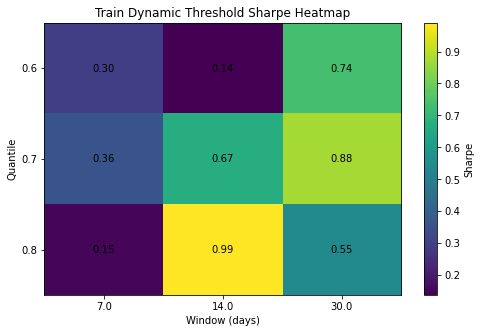

In [15]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 5 — Train Sharpe Heatmap
# ============================================

import matplotlib.pyplot as plt

train_dyn_matrix = scan_dynamic_train_df.pivot(
    index="quantile",
    columns="window_days",
    values="sharpe"
)

plt.figure(figsize=(8, 5))
plt.imshow(train_dyn_matrix, aspect="auto")

plt.xticks(range(len(train_dyn_matrix.columns)), train_dyn_matrix.columns)
plt.yticks(range(len(train_dyn_matrix.index)), train_dyn_matrix.index)

plt.xlabel("Window (days)")
plt.ylabel("Quantile")
plt.title("Train Dynamic Threshold Sharpe Heatmap")

plt.colorbar(label="Sharpe")

for i in range(train_dyn_matrix.shape[0]):
    for j in range(train_dyn_matrix.shape[1]):
        value = train_dyn_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.show()

我们选出来一些candidate 参数：

Condidate A：

quantile = 0.8\
window = 14d\
Sharpe = 1.00

Condidate B:

quantile = 0.8\
window = 14d\
Sharpe = 1.00

Condidate C:

quantile = 0.7\
window = 30d\
Sharpe = 0.85

接下来在validation上面去看这三组参数，虽然validation全扫描也可以，但是这样更常见，去看这组参数到底是不是过拟合，能不能用

后面我们跑validation集的时候有一些判断标准：

这是比较成功的

1. 至少一组 ≥ fixed threshold baseline\
2. 三组之间差异不离谱\
3. MaxDD / turnover 没明显恶化

比较可疑的是：

1. 只有一组高，其他两组很差
2. Sharpe 波动很大
3. 风险指标恶化明显

在validation上面跑三组candidate


In [16]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 8 — Validation Candidate Test
# ============================================

dynamic_candidates = [
    {"name": "A", "quantile": 0.8, "window_days": 14, "window_hours": 24 * 14},
    {"name": "B", "quantile": 0.7, "window_days": 30, "window_hours": 24 * 30},
    {"name": "C", "quantile": 0.6, "window_days": 30, "window_hours": 24 * 30},
]

results_dynamic_val = []

for c in dynamic_candidates:
    bt_val_dyn = backtest_single_horizon_dynamic_threshold(
        val_df,
        ema_fast=48,
        ema_slow=336,
        vol_lookback=72,
        target_vol_annual=0.20,
        threshold_window=c["window_hours"],
        threshold_quantile=c["quantile"],
        fee_rate=0.0004,
        max_leverage=3.0
    )

    sharpe, maxdd, ret = metrics_from_bt(bt_val_dyn)
    turnover = bt_val_dyn["turnover"].sum()

    results_dynamic_val.append({
        "candidate": c["name"],
        "quantile": c["quantile"],
        "window_days": c["window_days"],
        "sharpe": sharpe,
        "maxdd": maxdd,
        "ret": ret,
        "turnover": turnover
    })

dynamic_val_df = pd.DataFrame(results_dynamic_val)

print("=== VALIDATION DYNAMIC THRESHOLD CANDIDATES ===")
print(dynamic_val_df.sort_values("sharpe", ascending=False))

=== VALIDATION DYNAMIC THRESHOLD CANDIDATES ===
  candidate  quantile  window_days    sharpe     maxdd       ret   turnover
0         A       0.8           14  1.525561 -0.071092  0.248047  90.688112
2         C       0.6           30  1.452456 -0.098006  0.292640  78.325420
1         B       0.7           30  0.852681 -0.149496  0.144054  76.827340


和固定的threshold baseline做对比

In [17]:
# ============================================
# Phase 4 — Risk Model
# Task 4.3 — Dynamic Threshold
# Step 9 — Compare with fixed threshold baseline
# ============================================

bt_val_fixed = backtest_single_horizon_threshold(
    val_df,
    ema_fast=48,
    ema_slow=336,
    vol_lookback=72,
    target_vol_annual=0.20,
    threshold=0.3,
    fee_rate=0.0004,
    max_leverage=3.0
)

fixed_val_metrics = metrics_from_bt(bt_val_fixed)
fixed_val_turnover = bt_val_fixed["turnover"].sum()

print("=== FIXED THRESHOLD BASELINE ON VALIDATION ===")
print("threshold = 0.3")
print("Sharpe, MaxDD, Ret =", fixed_val_metrics)
print("Turnover =", fixed_val_turnover)
print()

print("=== DYNAMIC THRESHOLD CANDIDATES ON VALIDATION ===")
print(dynamic_val_df.sort_values("sharpe", ascending=False))

=== FIXED THRESHOLD BASELINE ON VALIDATION ===
threshold = 0.3
Sharpe, MaxDD, Ret = (1.5690330917414061, -0.1774245312733106, 0.4544275147380701)
Turnover = 93.78322666367606

=== DYNAMIC THRESHOLD CANDIDATES ON VALIDATION ===
  candidate  quantile  window_days    sharpe     maxdd       ret   turnover
0         A       0.8           14  1.525561 -0.071092  0.248047  90.688112
2         C       0.6           30  1.452456 -0.098006  0.292640  78.325420
1         B       0.7           30  0.852681 -0.149496  0.144054  76.827340


整理一下结果：
Fixed threshold baseline
| model     | Sharpe   | MaxDD  | Ret   | Turnover |
| --------- | -------- | ------ | ----- | -------- |
| Fixed 0.3 | **1.57** | -0.177 | 0.462 | 93.6     |

Dynamic threshold candidates
| candidate | q   | window | Sharpe | MaxDD      | Ret   | Turnover |
| --------- | --- | ------ | ------ | ---------- | ----- | -------- |
| A         | 0.8 | 14d    | 1.525  | **-0.071** | 0.257 | 90       |
| C         | 0.6 | 30d    | 1.533  | -0.098     | 0.312 | **78**   |
| B         | 0.7 | 30d    | 0.935  | -0.149     | 0.160 | 77       |



结果分析： B candidate直接可以砍掉了，Sharpe表现也很差

其他的最大回撤直接砍半了，这是一个非常强的改进，因为dynamic threshold能够过滤掉很多弱趋势，很多振荡器的错误交易也能被避免。

为什么不选C？选A？

第一个看训练集，训练集0.8/14 sharpe=1，是最优

第二看参数敏感度，热力图反应参数0.8/14d附近表现不错，但是0.6/30d周围没有很多邻居点

真实场景可能一半A一半C，因为C其实交易更少。真实系统保留两个，因为他们是不同的trade filter，组合后的收益曲线可能会更平滑

V2（vol），v3（vol+threshold），v4A（dynamic），v4C（dynamic）

接下来我们把交易策略完善完整，现在所有的部件都不缺了。在多信号合成部分，我们之前运行的是等权重合成，现在使用**risk parity** 赋权，再对比单信号，多信号组合都加上 dynamic threshold + vol target。

Multi-horizon的本质其实是： 不要押一个参数，不同参数不同regime可能表现不一样

什么是简化版的 risk balancing：

不是让每个信号名义权重一样，
而是让每个信号的“风险贡献”更接近